## 📱 Mobile Price Prediction
 
**Objective:** Predict mobile phone prices based on hardware specifications and features using regression analysis.

##### 📊 Dataset Column Description

- 'Product_id': The unique identifier for each mobile phone product.
- 'Price': The price of the mobile phone (in currency units).
- 'Sale': The number of units sold for that product.
- 'weight': The weight of the mobile phone (in grams).
- 'resoloution': The screen size / display resolution of the mobile phone (in inches).
- 'ppi': Pixels Per Inch — the pixel density of the display screen.
- 'cpu core': The number of CPU cores in the processor (e.g., 1 = single-core, 2 = dual-core, 4 = quad-core, 8 = octa-core).
- 'cpu freq': The CPU clock frequency / processor speed (in GHz).
- 'internal mem': The internal storage / memory capacity of the phone (in GB).
- 'ram': The RAM (Random Access Memory) of the phone (in GB).
- 'RearCam': The rear (back) camera resolution (in megapixels). A value of 0 indicates no rear camera.
- 'Front_Cam': The front-facing camera resolution (in megapixels). A value of 0 indicates no front camera.
- 'battery': The battery capacity of the mobile phone (in mAh).
- 'thickness': The thickness of the mobile phone body (in mm).

#### Importing necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

### Task 1: Data Preparation and Exploration

In [2]:
df=pd.read_csv('Cellphone.csv')
df.sample(5)

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
33,1020,2654,30,151.0,5.7,386,8,1.550,32.0,2.000,16.0,5.0,3050,5.9
108,832,1676,268,150.0,5.0,294,4,1.200,16.0,1.000,10.0,0.9,2200,8.5
127,1112,2491,455,753.0,12.2,247,8,1.600,32.0,3.000,8.0,2.0,9500,8.0
149,826,614,2159,69.8,1.4,129,0,0.000,0.0,0.004,0.0,0.0,800,14.1
86,1026,791,114,66.0,1.5,121,1,0.208,0.0,0.004,0.0,0.0,800,13.2


In [3]:

print(f'Number of null values in each column: {df.isnull().sum()}')

Number of null values in each column: Product_id      0
Price           0
Sale            0
weight          0
resoloution     0
ppi             0
cpu core        0
cpu freq        0
internal mem    0
ram             0
RearCam         0
Front_Cam       0
battery         0
thickness       0
dtype: int64


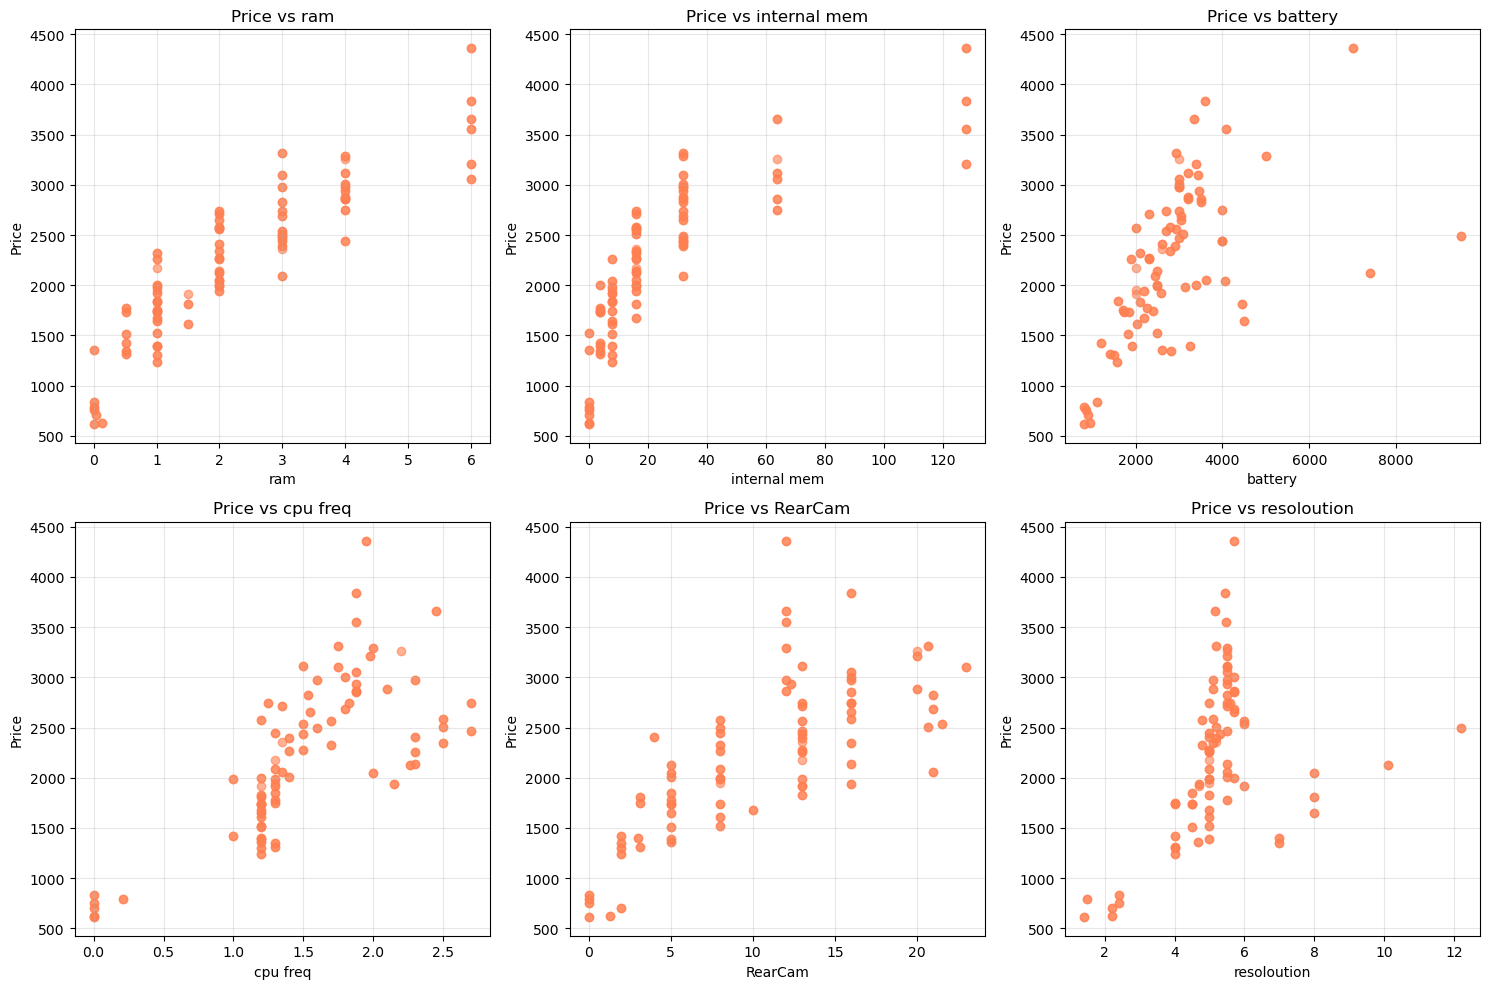

In [4]:
key_features = ['ram', 'internal mem', 'battery', 'cpu freq', 'RearCam', 'resoloution']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for idx, feature in enumerate(key_features):
    axes[idx].scatter(df[feature], df['Price'], alpha=0.6, color='coral')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Price')
    axes[idx].set_title(f'Price vs {feature}')
    axes[idx].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Part 1: Exploring Feature Relationships
 
Looking at our scatter plots, we can see how different mobile phone features relate to price. Let's read what the data is telling us:
 
**The RAM Story** 
When we plot Price vs RAM, we notice distinct vertical bands moving upward. Mobile phones with 1GB RAM cluster around ₹1,500-₹2,000, phones with 2GB RAM jump to ₹2,000-₹2,500, and 4GB+ RAM phones reach ₹3,000-₹4,000+. This clear upward trend tells us: **more RAM consistently means higher prices** - a textbook example of a linear relationship!
 
**The Storage Pattern** 
Similarly, internal memory shows vertical columns ascending from left to right. Phones with 4GB storage stay in the lower price range, while 32GB and 64GB devices command premium prices. Again, we see **a clear linear progression**.
 
**The Battery Effect** 
Battery capacity displays a positive trend - as battery size increases from 1,500mAh to 4,000mAh+, prices generally climb upward. While there's some scatter, the overall direction is unmistakably upward.
 
**The Scattered Features** 
However, not all features show such clean patterns. CPU frequency and camera specifications are more scattered, suggesting these relationships might be complex or influenced by other factors. But the overall trend? Still positive and relatively linear.

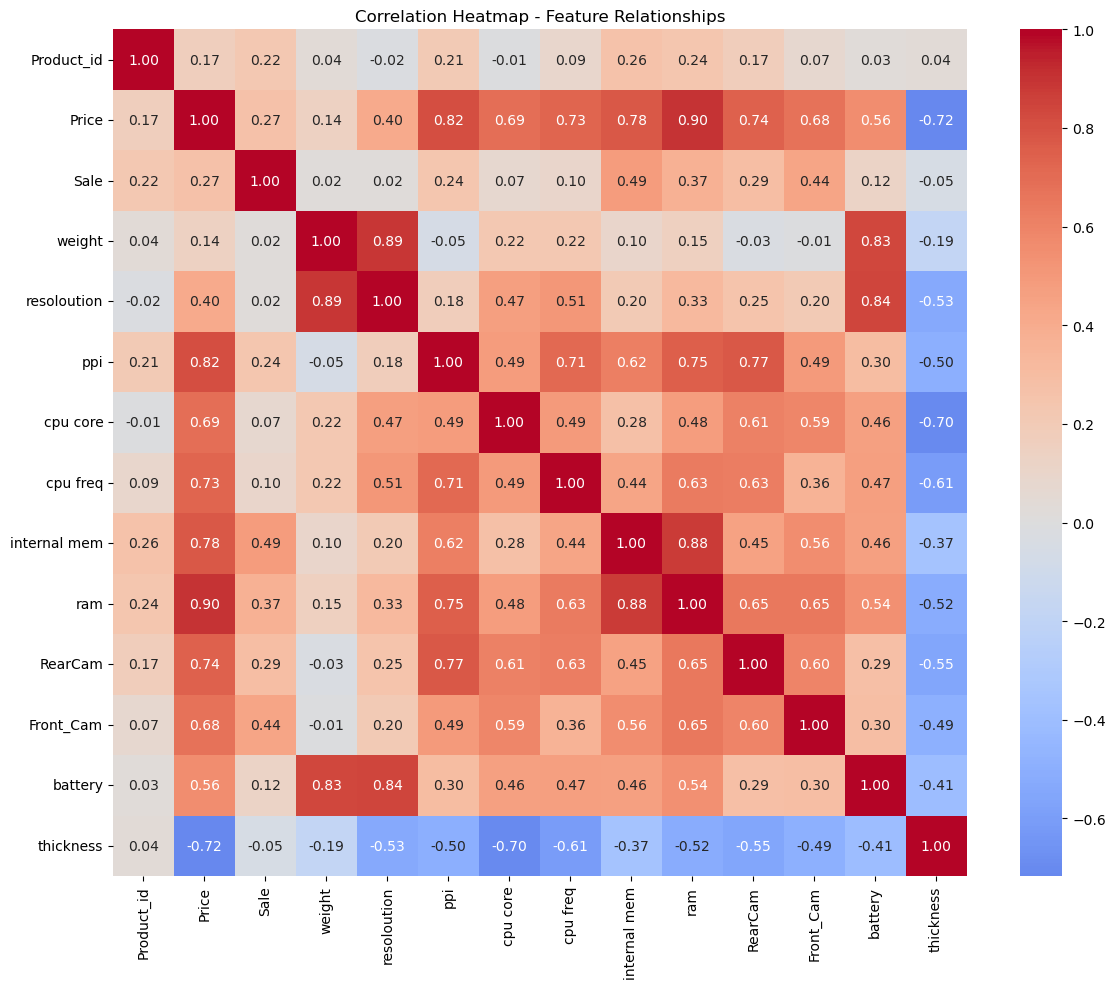

In [5]:
# Calculate correlation with Price
correlation = df.corr()['Price'].sort_values(ascending=False)
# Visualize correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Feature Relationships')
plt.tight_layout()
plt.show()

##### Part 2: The Correlation Detective Work 🔍
 
Our correlation heatmap reveals the strength of these relationships numerically:
 
**The Power Players** (Strong Positive Correlations with Price):
- **RAM (0.90)**: The champion! Nearly perfect linear relationship
- **PPI (0.82)**: Screen quality matters significantly
- **Internal Memory (0.78)**: Storage capacity is a major price driver
- **Camera Quality (0.74)**: Better cameras = premium phones
- **CPU Frequency (0.73)**: Processing power adds value
- **CPU Cores (0.69)**: More cores = higher price point
 
**The Surprise Finding**:
- **Thickness (-0.72)**: Negative correlation! Thinner phones are MORE expensive - consumers pay premium for sleek designs
 
**The Weak Links**:
- Weight (0.14), Sale (0.27): These features barely influence price

#### 🎯 The Verdict: Why Simple Linear Regression is Our Best Starting Point
 
Based on our visual investigation, we can confidently conclude:
 
1. **Linear Patterns Dominate**: Multiple features (RAM, internal memory, battery, PPI) show clear straight-line relationships with price
 
2. **Strong Correlations**: Six features have correlations above 0.68, indicating robust linear associations
 
3. **Predictable Behavior**: As features increase, prices increase proportionally - this is exactly what linear regression models excel at capturing
 
4. **Interpretability**: Linear regression will give us clear coefficients showing "for every 1GB increase in RAM, price increases by ₹X" - perfect for business insights
 
**Therefore, we'll start with Simple Linear Regression as our baseline model.** If the model performs well (R² > 0.70), we've found our answer. If it underperforms, we can then explore more complex models like Random Forest or Polynomial Regression.
 
> **Machine Learning Best Practice**: Always start simple, understand the baseline, then add complexity only if needed!

### Task 2: Data Preprocessing

In [6]:
df_clean = df.drop(['Product_id', 'Sale'], axis=1)
df_clean.head()

,Price,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,2357,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,1749,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,1916,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,1315,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,1749,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9


In [7]:
df_clean.shape

(161, 12)

In [8]:
df_clean.isnull().sum()

Price           0
weight          0
resoloution     0
ppi             0
cpu core        0
cpu freq        0
internal mem    0
ram             0
RearCam         0
Front_Cam       0
battery         0
thickness       0
dtype: int64

#### Why We Removed Product_id and Sale
 
##### Product_id ❌
- **Just an identifier** - like a serial number or ID tag
- **No predictive value** - the ID number has no relationship to phone quality or price
- **Correlation: 0.17** - very weak, almost random
- **Example**: Phone ID #203 vs #880 tells us nothing about their features or price
 
##### Sale ❌
- **Data Leakage Problem** - represents units sold or sales volume
- **Reverse causation**: High sales might be CAUSED by low price, not a predictor OF price
- **Not a phone specification** - RAM, camera, battery are specs; sales volume is not
- **Won't exist for new phones** - when predicting price of a new phone model, we won't know its sales yet
- **Correlation: 0.27** - weak relationship anyway
 


### Task 3: Model Training

In [9]:
# Separate features and target
X = df_clean.drop('Price', axis=1)
y = df_clean['Price']

In [10]:
# Train-test split
from sklearn.model_selection import train_test_split
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Build Linear Regression Model
from sklearn.linear_model import LinearRegression
 
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [12]:
# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

### Task 4: Model evaluation

In [13]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("Training Performance:")
print(f"R² Score: {r2_score(y_train, y_train_pred):.4f}")
print(f"MSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}")
 
print("\nTesting Performance:")
print(f"R² Score: {r2_score(y_test, y_test_pred):.4f}")
print(f"MSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")

Training Performance:
R² Score: 0.9507
MSE: 170.68

Testing Performance:
R² Score: 0.9588
MSE: 152.83


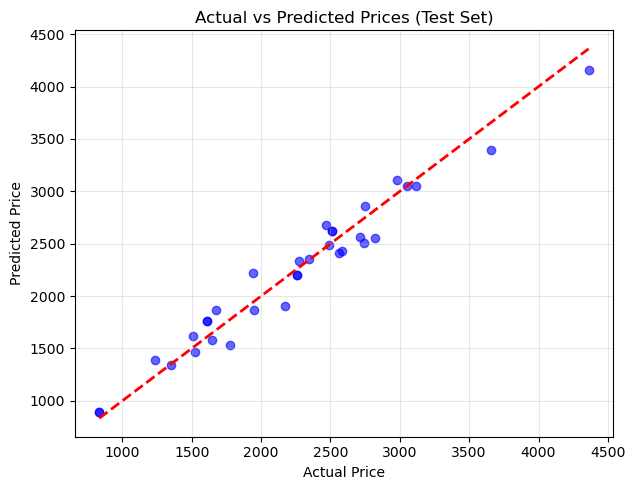

In [14]:
# Visualize: Actual vs Predicted
plt.figure(figsize=(12, 5))
 
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices (Test Set)')
plt.grid(True, alpha=0.3)
 
 
plt.tight_layout()
plt.show()

In [15]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)
 
feature_importance

,Feature,Coefficient
4,cpu freq,128.430783
6,ram,109.505576
3,cpu core,50.560082
5,internal mem,4.807445
8,Front_Cam,3.973639
7,RearCam,1.941315
2,ppi,1.139031
9,battery,0.136805
0,weight,-0.862902
1,resoloution,-54.266499


In [16]:
new_phone = pd.DataFrame({
    'weight': [150], 'resoloution': [5.5], 'ppi': [400],
    'cpu core': [8], 'cpu freq': [2.0], 'internal mem': [64],
    'ram': [4], 'RearCam': [16], 'Front_Cam': [8],
    'battery': [3000], 'thickness': [7.5]
})
predicted_price = model.predict(new_phone)
print(f"Predicted Price: ₹{predicted_price[0]:.2f}")

Predicted Price: ₹3045.75


In [17]:
import joblib
joblib.dump(model, 'mobile_price_model.pkl')

['mobile_price_model.pkl']